In [1]:
import pandas as pd

url = "https://gist.githubusercontent.com/vivek2606/88ec0800798ee7bf8540193acde83553/raw/heart.csv"
df = pd.read_csv(url)

print(df.head())

   age  sex  pain type   BP  cholestrol  fbs  resting ecg  max heart rate  \
0   70    1          4  130         322    0            2             109   
1   67    0          3  115         564    0            2             160   
2   57    1          2  124         261    0            0             141   
3   64    1          4  128         263    0            0             105   
4   74    0          2  120         269    0            2             121   

   exercise angina  ST depression  ST slope  flouroscopy coloured  thal  \
0                0            2.4         2                     3     3   
1                0            1.6         2                     0     7   
2                0            0.3         1                     0     7   
3                1            0.2         2                     1     7   
4                1            0.2         1                     1     3   

   heart disease  
0              2  
1              1  
2              2  
3         

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define features and target
X = df.drop("heart disease", axis=1)
y = df["heart disease"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9259259259259259
Precision: 0.9271512113617377
Recall: 0.9259259259259259
F1 Score: 0.9251633986928105
Confusion Matrix:
 [[32  1]
 [ 3 18]]


C:\Users\dibye\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dataset
url = "https://gist.githubusercontent.com/vivek2606/88ec0800798ee7bf8540193acde83553/raw/heart.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())

   age  sex  pain type   BP  cholestrol  fbs  resting ecg  max heart rate  \
0   70    1          4  130         322    0            2             109   
1   67    0          3  115         564    0            2             160   
2   57    1          2  124         261    0            0             141   
3   64    1          4  128         263    0            0             105   
4   74    0          2  120         269    0            2             121   

   exercise angina  ST depression  ST slope  flouroscopy coloured  thal  \
0                0            2.4         2                     3     3   
1                0            1.6         2                     0     7   
2                0            0.3         1                     0     7   
3                1            0.2         2                     1     7   
4                1            0.2         1                     1     3   

   heart disease  
0              2  
1              1  
2              2  
3         

In [10]:
# Split features and target variable

X = df.drop("heart disease", axis=1)
y = df["heart disease"]

In [11]:
# --- Train/test split ---

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

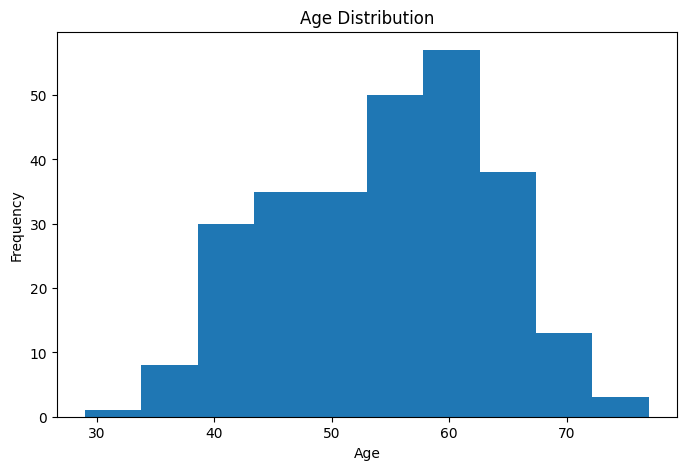

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

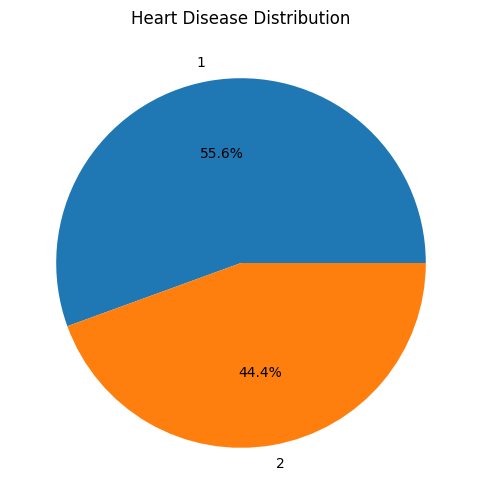

In [13]:
df['heart disease'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Heart Disease Distribution"
)

plt.ylabel("")
plt.show()

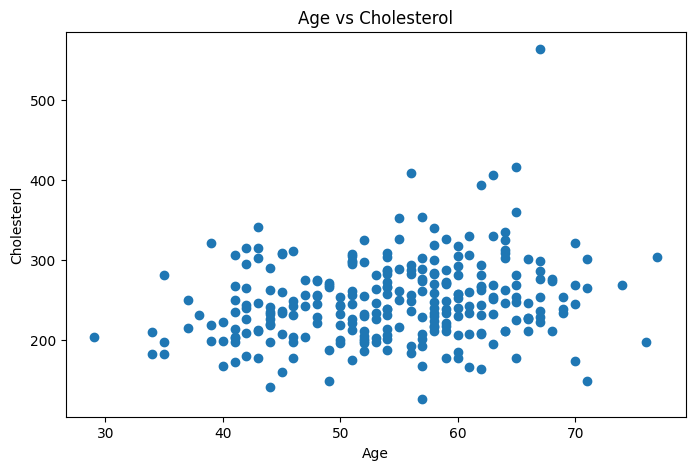

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['cholestrol'])
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

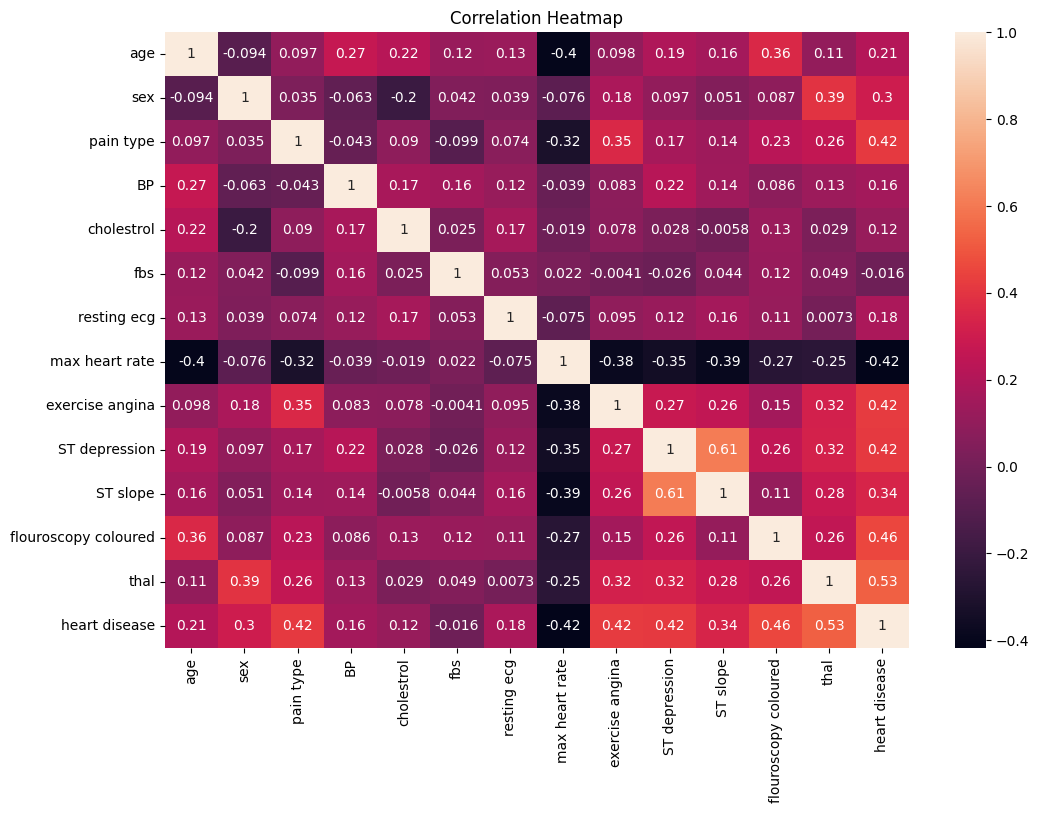

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

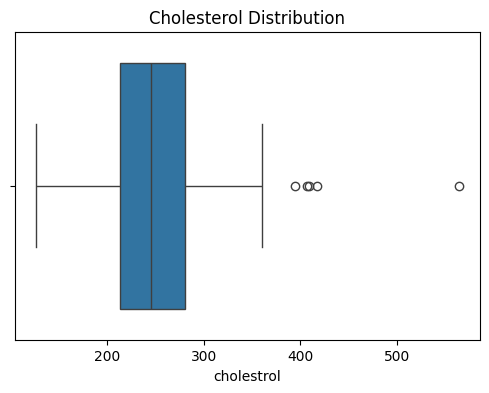

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['cholestrol'])
plt.title("Cholesterol Distribution")
plt.show()

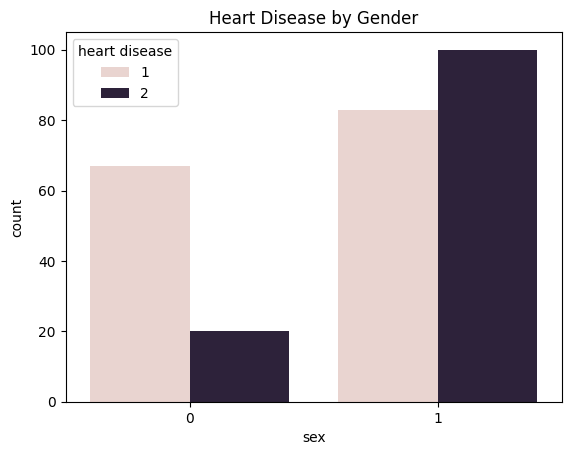

In [17]:
sns.countplot(x='sex', hue='heart disease', data=df)
plt.title("Heart Disease by Gender")
plt.show()

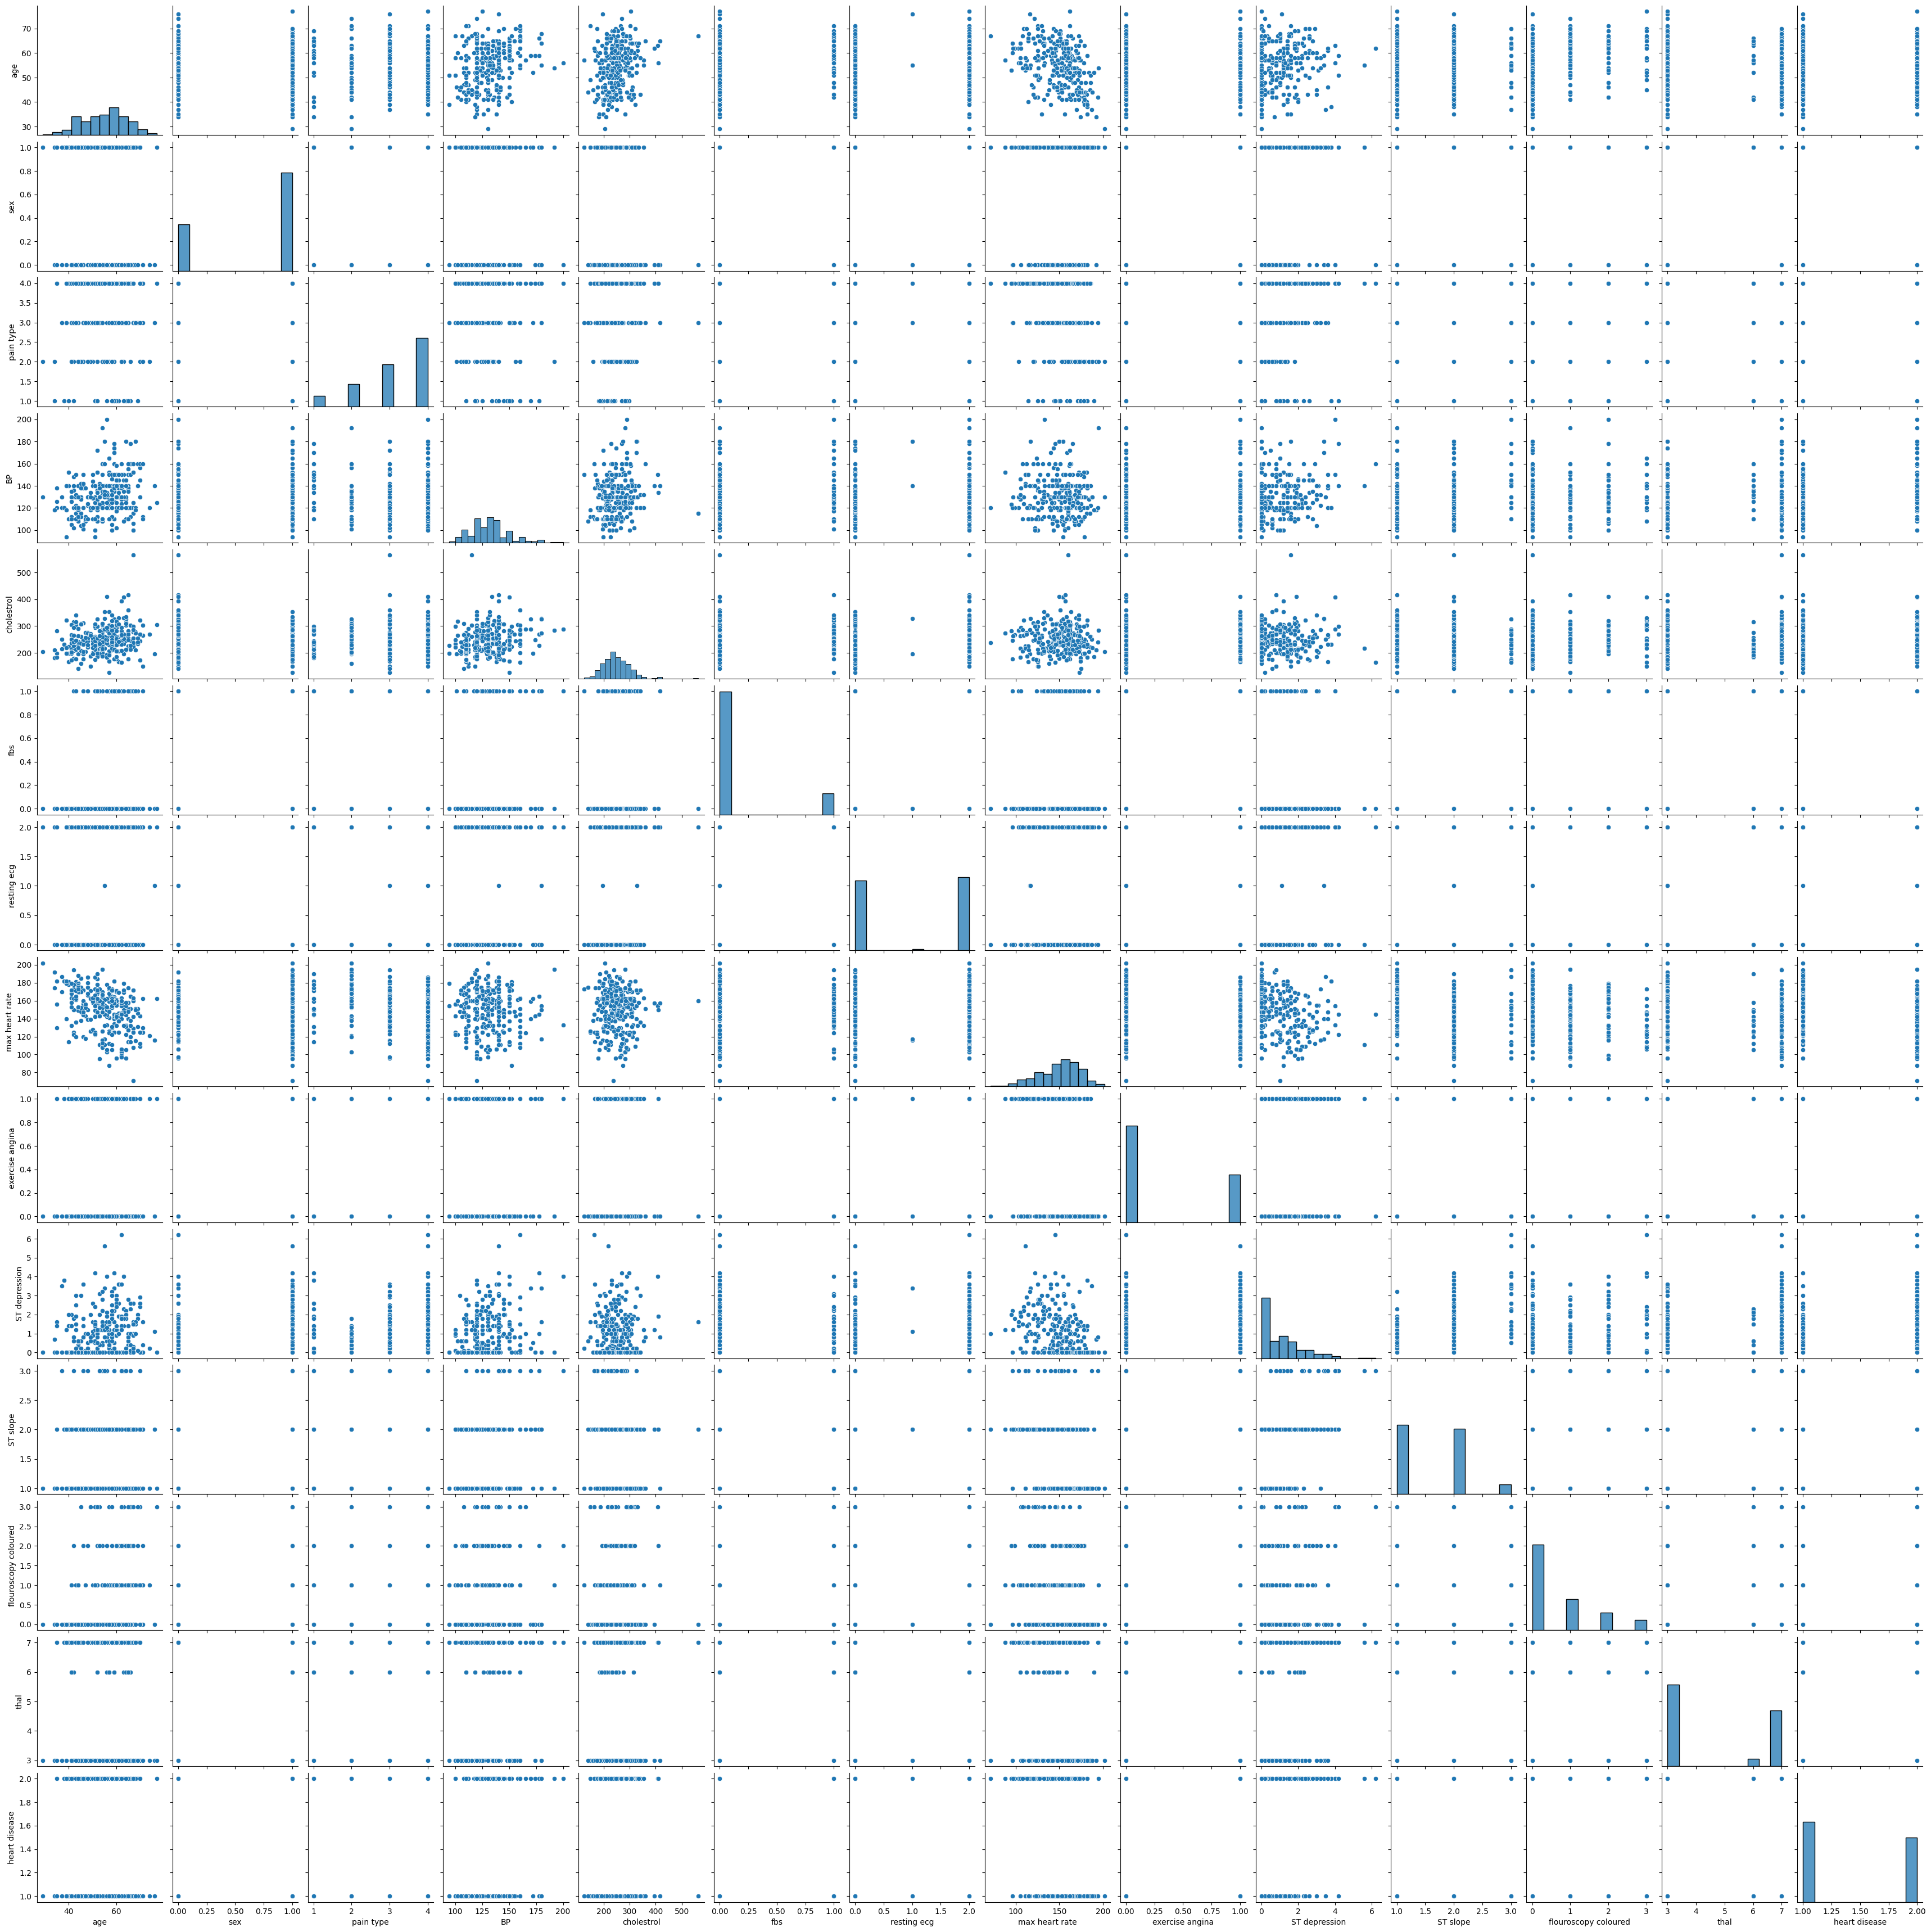

In [18]:
sns.pairplot(df)
plt.show()

In [19]:
# --- Train Logistic Regression ---

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

C:\Users\dibye\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [20]:
fig = px.scatter(
    df,
    x="age",
    y="cholestrol",
    animation_frame="heart disease",
    size="max heart rate",
    color="sex",
    title="Animated Heart Disease Visualization"
)

fig.show()

In [21]:
fig = px.histogram(
    df,
    x="age",
    color="heart disease",
    animation_frame="sex",
    title="Animated Age Distribution"
)

fig.show()

In [22]:
print("Dataset Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())
print("Summary Statistics:\n", df.describe())

Dataset Shape: (270, 14)
Missing Values:
 age                     0
sex                     0
pain type               0
BP                      0
cholestrol              0
fbs                     0
resting ecg             0
max heart rate          0
exercise angina         0
ST depression           0
ST slope                0
flouroscopy coloured    0
thal                    0
heart disease           0
dtype: int64
Summary Statistics:
               age         sex   pain type          BP  cholestrol         fbs  \
count  270.000000  270.000000  270.000000  270.000000  270.000000  270.000000   
mean    54.433333    0.677778    3.174074  131.344444  249.659259    0.148148   
std      9.109067    0.468195    0.950090   17.861608   51.686237    0.355906   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  213.000000    0.000000   
50%     55.000000    1.000000    3.000000  130.000000  245.000000    0.000

In [26]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import confusion_matrix

# Get probability predictions
y_probs = model.predict_proba(X_test)[:, 1]

# Create list of thresholds
thresholds = np.arange(0.1, 1.0, 0.1)

# Create frames for animation
frames = []
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    frames.append(go.Frame(
        data=[go.Heatmap(
            z=cm,
            x=['Negative', 'Positive'],
            y=['Negative', 'Positive'],
            text=cm,
            texttemplate='%{text}',
            colorscale='Blues'
        )],
        name=str(round(threshold, 1))
    ))

# Create initial heatmap
y_pred_init = (y_probs >= thresholds[0]).astype(int)
cm_init = confusion_matrix(y_test, y_pred_init)

fig = go.Figure(
    data=[go.Heatmap(
        z=cm_init,
        x=['Negative', 'Positive'],
        y=['Negative', 'Positive'],
        text=cm_init,
        texttemplate='%{text}',
        colorscale='Blues'
    )],
    frames=frames
)

fig.update_layout(
    title=f"Animated Confusion Matrix (Threshold: {thresholds[0]:.1f})",
    xaxis_title="Predicted",
    yaxis_title="Actual",
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 500}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]}
        ]
    }],
    sliders=[{
        'active': 0,
        'steps': [{'args': [[f.name], {'frame': {'duration': 300}, 'mode': 'immediate'}],
                  'label': f'Threshold: {f.name}', 'method': 'animate'} for f in frames],
        'transition': {'duration': 300}
    }]
)

fig.show()

C:\Users\dibye\AppData\Local\Temp\ipykernel_13548\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\dibye\AppData\Local\Temp\ipykernel_13548\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\dibye\AppData\Local\Temp\ipykernel_13548\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\dibye\AppData\Local\Temp\ipykernel_13548\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\dibye\AppData\Local\Temp\ipykernel_13548\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\dibye\AppData\Local\Temp\ipykernel_13548\13707